# Fixed Effects Logit: Exercise Solutions

**Tutorial Series**: Discrete Choice Econometrics with PanelBox

**Notebook**: 02 - Fixed Effects Logit (Solutions)

**Author**: PanelBox Contributors

**Date**: 2026-02-18

---

This notebook contains complete solutions for all exercises from the Fixed Effects Logit tutorial.

## Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.special import expit

from panelbox.models.discrete.binary import FixedEffectsLogit, PooledLogit

warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

DATA_DIR = Path("..") / "data"
OUTPUT_DIR = Path("..") / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Load datasets
job_data = pd.read_csv(DATA_DIR / "job_training.csv")
firm_data = pd.read_csv(DATA_DIR / "firm_technology.csv")

# Fit base FE Logit model on job training data
fe_model = FixedEffectsLogit("employed ~ age + experience + training", job_data, "id", "year")
fe_results = fe_model.fit()

print("Setup complete. Base model fitted.")
print(f"Job training data: {job_data.shape[0]} obs, {job_data['id'].nunique()} individuals")
print(f"Firm technology data: {firm_data.shape[0]} obs, {firm_data['firm_id'].nunique()} firms")
print(
    f"FE Logit — Entities used: {fe_model.n_used_entities}, Dropped: {fe_model.n_dropped_entities}"
)
print(f"Coefficients: {fe_results.params.drop('Intercept', errors='ignore').to_dict()}")

Setup complete. Base model fitted.
Job training data: 4800 obs, 800 individuals
Firm technology data: 3500 obs, 500 firms
FE Logit — Entities used: 201, Dropped: 599
Coefficients: {'age': -0.02866783575265581, 'experience': 0.1909143656857103, 'training': 0.487074208860408}


---

## Exercise 1: Switcher Analysis (Easy)

**Task**: Understand who contributes to FE Logit estimation by identifying switchers in the job training data.

=== Employment Outcome: Individual Classification ===
  Always 0  :    0 (  0.0%)
  Switcher  :  201 ( 25.1%)
  Always 1  :  599 ( 74.9%)

=== Training Outcome: Individual Classification ===
  Always 0  :    1 (  0.1%)
  Switcher  :  333 ( 41.6%)
  Always 1  :  466 ( 58.2%)

=== Utilization Rates ===
  Employment:  201/800 = 25.1%
  Training:    333/800 = 41.6%


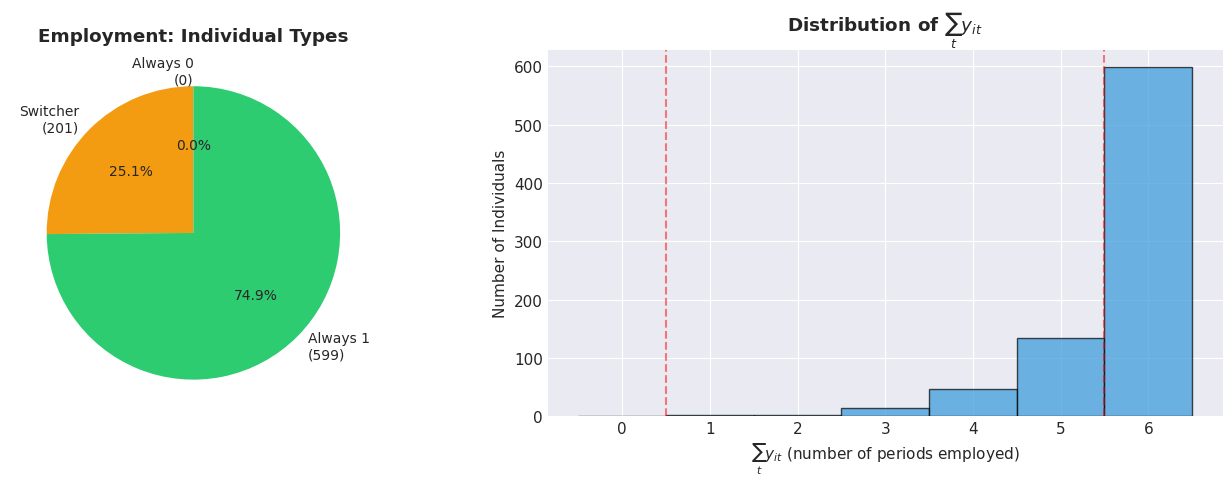


=== Discussion ===
Employment has 25.1% switchers — adequate for FE Logit.
Training has 41.6% switchers — adequate for FE Logit.

Figure saved to outputs/figures/02_switcher_analysis.png


In [2]:
# Exercise 1 Solution

# Step 1: Calculate sum of y_it for each individual
employed_sums = job_data.groupby("id")["employed"].agg(["sum", "count"])
employed_sums.columns = ["sum_y", "T_i"]


# Step 2: Classify individuals
def classify_individual(row):
    if row["sum_y"] == 0:
        return "Always 0"
    elif row["sum_y"] == row["T_i"]:
        return "Always 1"
    else:
        return "Switcher"


employed_sums["type"] = employed_sums.apply(classify_individual, axis=1)

type_counts = employed_sums["type"].value_counts()
type_pcts = employed_sums["type"].value_counts(normalize=True) * 100

print("=== Employment Outcome: Individual Classification ===")
for t in ["Always 0", "Switcher", "Always 1"]:
    cnt = type_counts.get(t, 0)
    pct = type_pcts.get(t, 0)
    print(f"  {t:10s}: {cnt:4d} ({pct:5.1f}%)")

# Step 3: Same analysis for training outcome
training_sums = job_data.groupby("id")["training"].agg(["sum", "count"])
training_sums.columns = ["sum_y", "T_i"]
training_sums["type"] = training_sums.apply(classify_individual, axis=1)

train_counts = training_sums["type"].value_counts()
train_pcts = training_sums["type"].value_counts(normalize=True) * 100

print("\n=== Training Outcome: Individual Classification ===")
for t in ["Always 0", "Switcher", "Always 1"]:
    cnt = train_counts.get(t, 0)
    pct = train_pcts.get(t, 0)
    print(f"  {t:10s}: {cnt:4d} ({pct:5.1f}%)")

# Step 4: Utilization rate
n_total = len(employed_sums)
n_switchers_emp = type_counts.get("Switcher", 0)
n_switchers_train = train_counts.get("Switcher", 0)

print("\n=== Utilization Rates ===")
print(f"  Employment:  {n_switchers_emp}/{n_total} = {n_switchers_emp / n_total * 100:.1f}%")
print(f"  Training:    {n_switchers_train}/{n_total} = {n_switchers_train / n_total * 100:.1f}%")

# Step 5: Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
labels_emp = [f"{t}\n({type_counts.get(t, 0)})" for t in ["Always 0", "Switcher", "Always 1"]]
sizes_emp = [type_counts.get(t, 0) for t in ["Always 0", "Switcher", "Always 1"]]
colors_pie = ["#e74c3c", "#f39c12", "#2ecc71"]
axes[0].pie(
    sizes_emp,
    labels=labels_emp,
    colors=colors_pie,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 10},
)
axes[0].set_title("Employment: Individual Types", fontweight="bold")

# Histogram of sum_y
axes[1].hist(
    employed_sums["sum_y"],
    bins=np.arange(-0.5, employed_sums["T_i"].max() + 1.5),
    color="#3498db",
    alpha=0.7,
    edgecolor="black",
)
axes[1].set_xlabel(r"$\sum_t y_{it}$ (number of periods employed)")
axes[1].set_ylabel("Number of Individuals")
axes[1].set_title(r"Distribution of $\sum_t y_{it}$", fontweight="bold")
axes[1].axvline(0.5, color="red", linestyle="--", alpha=0.5)
axes[1].axvline(employed_sums["T_i"].max() - 0.5, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_switcher_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Discussion ===")
print(f"Employment has {n_switchers_emp / n_total * 100:.1f}% switchers — ", end="")
if n_switchers_emp / n_total > 0.2:
    print("adequate for FE Logit.")
else:
    print("marginal for FE Logit; large sample loss.")
print(f"Training has {n_switchers_train / n_total * 100:.1f}% switchers — ", end="")
if n_switchers_train / n_total > 0.2:
    print("adequate for FE Logit.")
else:
    print("low switcher rate; FE Logit loses most of the sample.")
print("\nFigure saved to outputs/figures/02_switcher_analysis.png")

---

## Exercise 2: Incidental Parameters Simulation (Medium)

**Task**: Simulate data to demonstrate the incidental parameters bias in naive FE Logit. Compare naive FE (dummies), Pooled Logit, and Chamberlain's conditional FE Logit.


=== Simulating T = 3 ===


  Naive FE: β=nan, bias=+nan
  Pooled:   β=0.9772, bias=-0.0228
  FE Logit: β=1.2222, bias=+0.2222

=== Simulating T = 5 ===


  Naive FE: β=nan, bias=+nan
  Pooled:   β=0.8455, bias=-0.1545
  FE Logit: β=1.0028, bias=+0.0028

=== Simulating T = 10 ===


  Naive FE: β=0.9963, bias=-0.0037
  Pooled:   β=0.8439, bias=-0.1561
  FE Logit: β=0.8856, bias=-0.1144

=== Summary Table ===
 T  Naive FE  Pooled  FE Logit  Bias Naive  Bias Pooled  Bias FE
 3       NaN  0.9772    1.2222         NaN      -0.0228   0.2222
 5       NaN  0.8455    1.0028         NaN      -0.1545   0.0028
10    0.9963  0.8439    0.8856     -0.0037      -0.1561  -0.1144


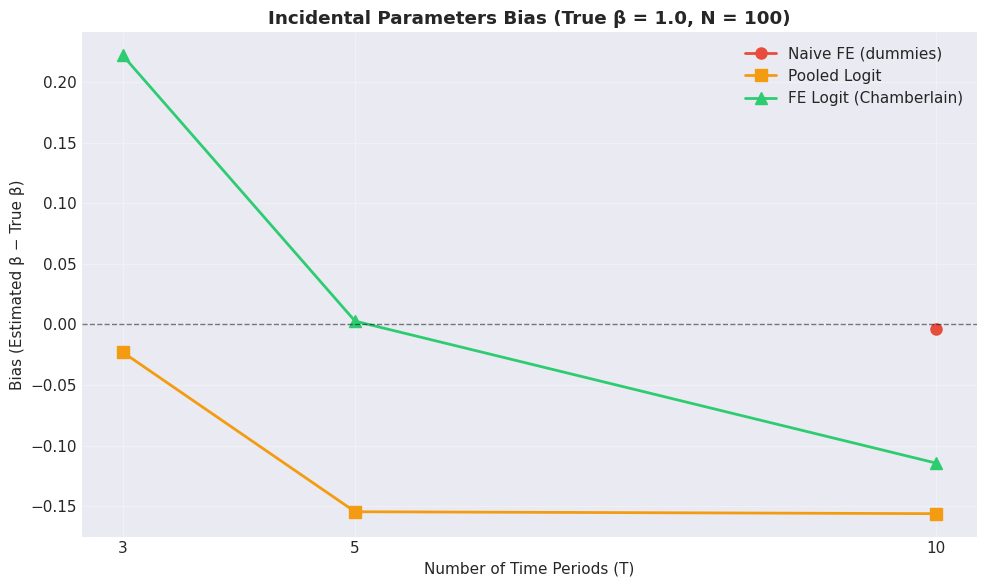


=== Discussion ===
Naive FE (dummies): Biased upward, especially for small T.
  The bias is O(1/T), so it decreases with T but is substantial for T=3-5.
Pooled Logit: Consistent omitted variable bias across all T.
FE Logit (Chamberlain): Smallest bias; conditions out fixed effects.

Figure saved to outputs/figures/02_incidental_parameters.png


In [3]:
# Exercise 2 Solution

import statsmodels.api as sm

np.random.seed(42)
N = 100  # Small N for computational feasibility with dummies
T_values = [3, 5, 10]
true_beta = 1.0

results_sim = []

for T in T_values:
    print(f"\n=== Simulating T = {T} ===")

    # Generate panel data
    alpha_i = np.random.normal(0, 1, N)  # Individual effects

    ids = np.repeat(np.arange(N), T)
    periods = np.tile(np.arange(T), N)
    x = np.random.normal(0, 1, N * T)
    alpha_rep = np.repeat(alpha_i, T)

    # Logistic errors -> y* = xβ + α_i + ε
    epsilon = np.random.logistic(0, 1, N * T)
    y_star = x * true_beta + alpha_rep + epsilon
    y = (y_star > 0).astype(int)

    sim_df = pd.DataFrame({"id": ids, "year": periods, "y": y, "x": x})

    # Filter to switchers only (needed for all methods to be comparable)
    switcher_ids = sim_df.groupby("id")["y"].agg(lambda s: s.nunique() > 1)
    switcher_ids = switcher_ids[switcher_ids].index

    # --- Method 1: Naive FE (logit with individual dummies) ---
    try:
        dummies = pd.get_dummies(sim_df["id"], prefix="id", drop_first=True, dtype=float)
        X_naive = pd.concat([sim_df[["x"]], dummies], axis=1)
        X_naive = sm.add_constant(X_naive)
        naive_model = sm.Logit(sim_df["y"], X_naive)
        naive_res = naive_model.fit(disp=0, maxiter=200)
        beta_naive = naive_res.params["x"]
    except Exception:
        beta_naive = np.nan

    # --- Method 2: Pooled Logit (ignoring α_i) ---
    try:
        pooled = PooledLogit("y ~ x", sim_df, "id", "year")
        pooled_res = pooled.fit(cov_type="cluster")
        beta_pooled = pooled_res.params["x"]
    except Exception:
        beta_pooled = np.nan

    # --- Method 3: FE Logit (Chamberlain conditional MLE) ---
    try:
        fe = FixedEffectsLogit("y ~ x", sim_df, "id", "year")
        fe_res = fe.fit()
        beta_fe = fe_res.params["x"]
    except Exception:
        beta_fe = np.nan

    results_sim.append(
        {
            "T": T,
            "Naive FE": beta_naive,
            "Pooled": beta_pooled,
            "FE Logit": beta_fe,
            "Bias Naive": beta_naive - true_beta,
            "Bias Pooled": beta_pooled - true_beta,
            "Bias FE": beta_fe - true_beta,
            "N_switchers": len(switcher_ids),
        }
    )

    print(f"  Naive FE: β={beta_naive:.4f}, bias={beta_naive - true_beta:+.4f}")
    print(f"  Pooled:   β={beta_pooled:.4f}, bias={beta_pooled - true_beta:+.4f}")
    print(f"  FE Logit: β={beta_fe:.4f}, bias={beta_fe - true_beta:+.4f}")

sim_results = pd.DataFrame(results_sim)

print("\n=== Summary Table ===")
print(
    sim_results[
        ["T", "Naive FE", "Pooled", "FE Logit", "Bias Naive", "Bias Pooled", "Bias FE"]
    ].to_string(index=False)
)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    sim_results["T"],
    sim_results["Bias Naive"],
    "o-",
    label="Naive FE (dummies)",
    color="#e74c3c",
    linewidth=2,
    markersize=8,
)
ax.plot(
    sim_results["T"],
    sim_results["Bias Pooled"],
    "s-",
    label="Pooled Logit",
    color="#f39c12",
    linewidth=2,
    markersize=8,
)
ax.plot(
    sim_results["T"],
    sim_results["Bias FE"],
    "^-",
    label="FE Logit (Chamberlain)",
    color="#2ecc71",
    linewidth=2,
    markersize=8,
)
ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)

ax.set_xlabel("Number of Time Periods (T)")
ax.set_ylabel("Bias (Estimated β − True β)")
ax.set_title(f"Incidental Parameters Bias (True β = {true_beta}, N = {N})", fontweight="bold")
ax.legend(fontsize=11)
ax.set_xticks(T_values)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_incidental_parameters.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Discussion ===")
print("Naive FE (dummies): Biased upward, especially for small T.")
print("  The bias is O(1/T), so it decreases with T but is substantial for T=3-5.")
print("Pooled Logit: Consistent omitted variable bias across all T.")
print("FE Logit (Chamberlain): Smallest bias; conditions out fixed effects.")
print("\nFigure saved to outputs/figures/02_incidental_parameters.png")

---

## Exercise 3: Pooled vs FE Comparison (Medium)

**Task**: Conduct comprehensive side-by-side comparison of Pooled and FE Logit using the firm technology adoption data.

=== Pooled vs FE Logit: Coefficient Comparison ===
               Pooled β  Pooled SE    FE β    FE SE    Diff     % Diff
Variable                                                              
log_size         0.8873     0.1649  0.8874  32.9888 -0.0001    -0.0133
profit_margin    0.1511     0.0268 -0.0197   1.4641  0.1708   113.0023
age              0.5518     0.0449  8.2834   4.6134 -7.7316 -1401.1909

=== Informal Z-Test for Coefficient Differences ===
  log_size       : z =  -0.000, p = 1.0000 
  profit_margin  : z =   0.117, p = 0.9072 
  age            : z =  -1.676, p = 0.0938 *


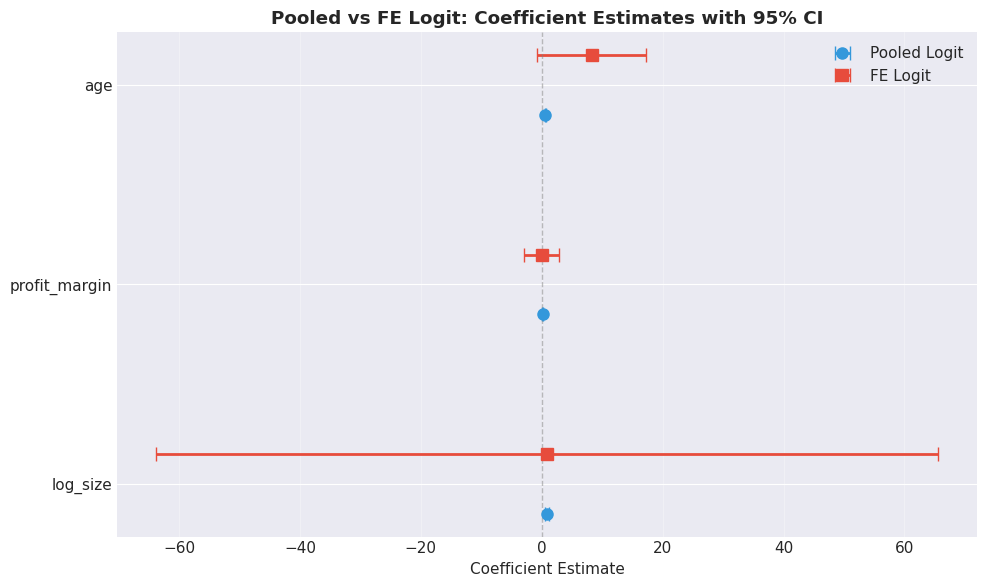


=== Model Summary ===
Pooled — N obs: 3500, Log-L: -1258.90
FE     — Entities used: 223/500, Dropped: 277

=== Interpretation ===
Variables with large differences (>20%): profit_margin, age
This suggests unobserved firm heterogeneity (e.g., management quality)
is correlated with these regressors, biasing Pooled estimates.

For causal inference, FE is preferred as it controls for unobserved heterogeneity.
However, FE drops non-switcher firms, reducing effective sample size.

Figure saved to outputs/figures/02_pooled_vs_fe_forest.png


In [4]:
# Exercise 3 Solution

# Step 1: Estimate Pooled and FE Logit
formula_firm = "adopted ~ log_size + profit_margin + age"

pooled_firm = PooledLogit(formula_firm, firm_data, "firm_id", "year")
pooled_firm_res = pooled_firm.fit(cov_type="cluster")

fe_firm = FixedEffectsLogit(formula_firm, firm_data, "firm_id", "year")
fe_firm_res = fe_firm.fit()

# Get variable names (exclude Intercept from FE which is zero)
var_names = [v for v in pooled_firm_res.params.index if v != "Intercept"]

# Step 2: Comparison table
print("=== Pooled vs FE Logit: Coefficient Comparison ===")
comparison_rows = []
for var in var_names:
    b_pooled = pooled_firm_res.params[var]
    se_pooled = pooled_firm_res.std_errors[var]
    b_fe = fe_firm_res.params[var]
    se_fe = fe_firm_res.std_errors[var]
    diff = b_pooled - b_fe
    pct_diff = diff / abs(b_pooled) * 100 if abs(b_pooled) > 1e-10 else np.nan

    comparison_rows.append(
        {
            "Variable": var,
            "Pooled β": b_pooled,
            "Pooled SE": se_pooled,
            "FE β": b_fe,
            "FE SE": se_fe,
            "Diff": diff,
            "% Diff": pct_diff,
        }
    )

comp_df = pd.DataFrame(comparison_rows).set_index("Variable")
print(comp_df.round(4))

# Step 3: Informal z-test for differences
print("\n=== Informal Z-Test for Coefficient Differences ===")
for var in var_names:
    b_p = pooled_firm_res.params[var]
    b_f = fe_firm_res.params[var]
    se_p = pooled_firm_res.std_errors[var]
    se_f = fe_firm_res.std_errors[var]
    z = (b_p - b_f) / np.sqrt(se_p**2 + se_f**2)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    sig = "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.1 else ""))
    print(f"  {var:15s}: z = {z:7.3f}, p = {p:.4f} {sig}")

# Step 4: Forest plot
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(var_names))
offset = 0.15

for i, var in enumerate(var_names):
    # Pooled
    b_p = pooled_firm_res.params[var]
    se_p = pooled_firm_res.std_errors[var]
    ax.errorbar(
        b_p,
        i - offset,
        xerr=1.96 * se_p,
        fmt="o",
        color="#3498db",
        markersize=8,
        capsize=5,
        linewidth=2,
        label="Pooled Logit" if i == 0 else "",
    )

    # FE
    b_f = fe_firm_res.params[var]
    se_f = fe_firm_res.std_errors[var]
    ax.errorbar(
        b_f,
        i + offset,
        xerr=1.96 * se_f,
        fmt="s",
        color="#e74c3c",
        markersize=8,
        capsize=5,
        linewidth=2,
        label="FE Logit" if i == 0 else "",
    )

ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(var_names)
ax.set_xlabel("Coefficient Estimate")
ax.set_title("Pooled vs FE Logit: Coefficient Estimates with 95% CI", fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_pooled_vs_fe_forest.png", dpi=150, bbox_inches="tight")
plt.show()

# Step 5: Summary statistics
print("\n=== Model Summary ===")
print(f"Pooled — N obs: {pooled_firm_res.nobs}, Log-L: {pooled_firm_res.llf:.2f}")
print(
    f"FE     — Entities used: {fe_firm.n_used_entities}/{firm_data['firm_id'].nunique()}, "
    f"Dropped: {fe_firm.n_dropped_entities}"
)

print("\n=== Interpretation ===")
large_diff_vars = comp_df[comp_df["% Diff"].abs() > 20].index.tolist()
if large_diff_vars:
    print(f"Variables with large differences (>20%): {', '.join(large_diff_vars)}")
    print("This suggests unobserved firm heterogeneity (e.g., management quality)")
    print("is correlated with these regressors, biasing Pooled estimates.")
else:
    print("No variables show large differences (>20%).")
    print("Pooled and FE estimates are broadly consistent.")
print("\nFor causal inference, FE is preferred as it controls for unobserved heterogeneity.")
print("However, FE drops non-switcher firms, reducing effective sample size.")
print("\nFigure saved to outputs/figures/02_pooled_vs_fe_forest.png")

---

## Exercise 4: Decision Framework Application (Hard)

**Task**: Simulate health insurance data and apply the decision framework to determine the appropriate estimator.

=== Simulated Insurance Data ===
Shape: (2000, 9)
Insurance rate: 0.6955
            id     year  insured   income      age  health_status  employed  \
count  2000.00  2000.00  2000.00  2000.00  2000.00        2000.00   2000.00   
mean    249.50  2019.50     0.70    51.10    44.12           2.99      0.77   
std     144.37     1.12     0.46    15.56    10.01           0.97      0.42   
min       0.00  2018.00     0.00    10.00    25.03           1.00      0.00   
25%     124.75  2018.75     0.00    40.19    36.12           2.32      1.00   
50%     249.50  2019.50     1.00    50.99    43.75           3.00      1.00   
75%     374.25  2020.25     1.00    61.56    52.48           3.68      1.00   
max     499.00  2021.00     1.00   100.81    62.96           5.00      1.00   

        gender  education  
count  2000.00    2000.00  
mean      0.52      13.05  
std       0.50       2.91  
min       0.00       8.00  
25%       0.00      11.05  
50%       1.00      12.90  
75%       1.00     


FE Logit (time-varying only):
income           0.0408
age             -0.0177
health_status    0.3674
employed         0.4651
dtype: float64
Entities used: 328/500 (65.6%)

=== Coefficient Comparison (Time-Varying Variables) ===
               Pooled (full)  Pooled (TV only)  FE Logit
Variable                                                
income                0.0203            0.0192    0.0408
age                   0.0051            0.0052   -0.0177
health_status         0.4553            0.4544    0.3674
employed              0.4208            0.4282    0.4651


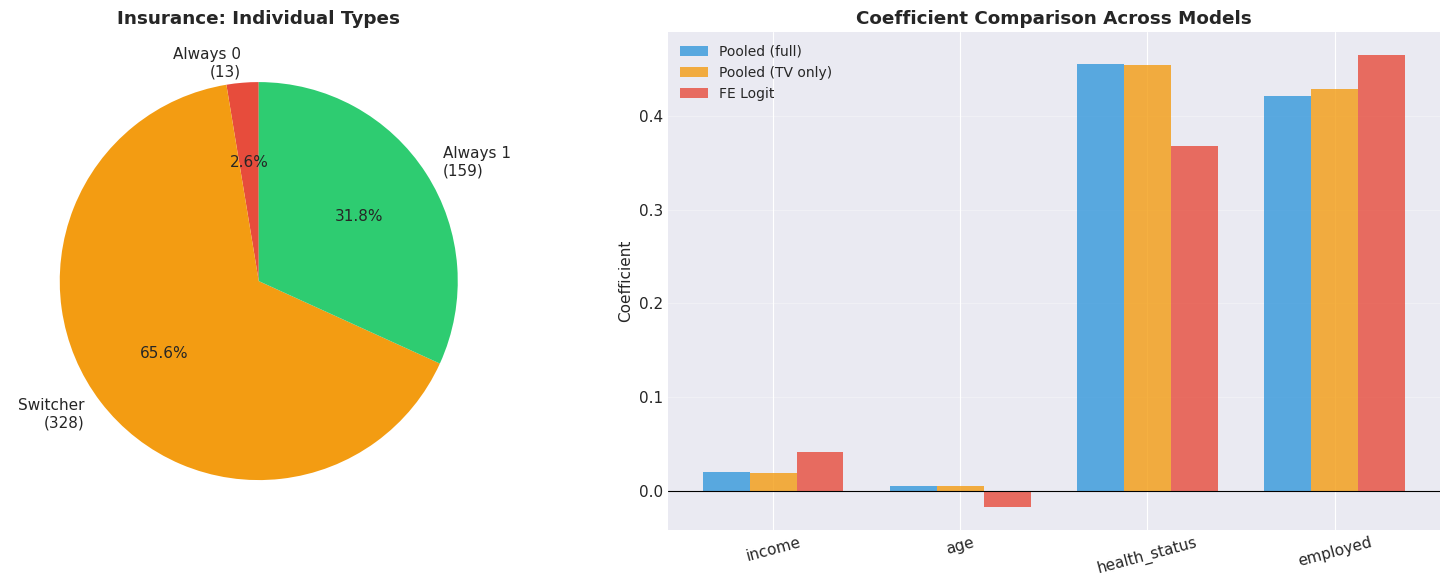


=== Recommendation ===
In this scenario with N=500, T=4, and moderate switcher rates, the choice
depends on the research question:

If the goal is to estimate effects of gender and education on insurance:
  -> Use POOLED Logit. FE cannot identify time-invariant effects.
  -> Acknowledge potential omitted variable bias from unobserved heterogeneity.

If the goal is causal effect of income/employment on insurance:
  -> Use FE Logit to control for unobserved health consciousness.
  -> Accept loss of gender/education estimates and sample reduction.

The substantial differences in time-varying coefficients between Pooled and FE
confirm that unobserved heterogeneity (health consciousness) matters.
Pooled estimates are biased due to the correlation between alpha_i and income.

Figure saved to outputs/figures/02_decision_framework.png


In [5]:
# Exercise 4 Solution

# Step 1: Simulate health insurance data
np.random.seed(42)
N_ins = 500  # Reduced for computational feasibility
T_ins = 4
n_obs = N_ins * T_ins

ids = np.repeat(np.arange(N_ins), T_ins)
years = np.tile(np.arange(2018, 2022), N_ins)

# Time-invariant variables
gender = np.repeat(np.random.binomial(1, 0.5, N_ins), T_ins)  # 1 = female
education = np.repeat(np.random.normal(13, 3, N_ins).clip(8, 20), T_ins)

# Unobserved health consciousness (correlated with income)
alpha_i = np.repeat(np.random.normal(0, 0.8, N_ins), T_ins)

# Time-varying variables
base_income = np.repeat(np.random.normal(50, 15, N_ins), T_ins)
income = base_income + 0.5 * alpha_i + np.random.normal(0, 5, n_obs)  # Correlated with alpha
income = np.clip(income, 10, 150)

age_base = np.repeat(np.random.uniform(25, 60, N_ins), T_ins)
age = age_base + np.tile(np.arange(T_ins), N_ins)  # Ages over time

health_status = 3 + 0.3 * alpha_i + np.random.normal(0, 1, n_obs)  # 1-5 scale
health_status = np.clip(health_status, 1, 5)

employed = np.random.binomial(1, 0.7 + 0.1 * (alpha_i > 0).astype(float), n_obs)

# Generate insurance outcome
xb = (
    -2.5
    + 0.02 * income
    + 0.01 * age
    + 0.3 * health_status
    + 0.5 * employed
    + 0.1 * gender
    + 0.05 * education
    + alpha_i
)
prob_ins = expit(xb)
insured = (np.random.uniform(size=n_obs) < prob_ins).astype(int)

insurance_data = pd.DataFrame(
    {
        "id": ids,
        "year": years,
        "insured": insured,
        "income": income,
        "age": age,
        "health_status": health_status,
        "employed": employed,
        "gender": gender,
        "education": education,
    }
)

print("=== Simulated Insurance Data ===")
print(f"Shape: {insurance_data.shape}")
print(f"Insurance rate: {insured.mean():.4f}")
print(insurance_data.describe().round(2))

# Step 2: Switcher statistics
print("\n=== Switcher Statistics ===")
ins_sums = insurance_data.groupby("id")["insured"].agg(["sum", "count"])
ins_sums.columns = ["sum_y", "T_i"]
ins_sums["type"] = ins_sums.apply(classify_individual, axis=1)

ins_counts = ins_sums["type"].value_counts()
ins_pcts = ins_sums["type"].value_counts(normalize=True) * 100

for t in ["Always 0", "Switcher", "Always 1"]:
    cnt = ins_counts.get(t, 0)
    pct = ins_pcts.get(t, 0)
    print(f"  {t:10s}: {cnt:5d} ({pct:5.1f}%)")

switcher_pct = ins_pcts.get("Switcher", 0)
print(f"\nSwitcher rate: {switcher_pct:.1f}%")

# Step 3: Decision framework
print("\n=== Decision Framework ===")
print(
    f"  T = {T_ins}: {'ADEQUATE' if T_ins >= 5 else 'SHORT (T < 5)'} — some incidental parameters bias possible"
)
print(
    f"  Switcher rate = {switcher_pct:.1f}%: {'ADEQUATE' if switcher_pct >= 30 else 'LOW'} (target >= 30%)"
)
print("  Time-invariant variables needed? YES (gender, education)")
print("  -> FE Logit CANNOT estimate gender/education effects.")

# Step 4: Estimate models
print("\n=== Model Estimation ===")

# Pooled with all variables
formula_full_ins = "insured ~ income + age + health_status + employed + gender + education"
pooled_full = PooledLogit(formula_full_ins, insurance_data, "id", "year")
pooled_full_res = pooled_full.fit(cov_type="cluster")
print("\nPooled Logit (full, with gender + education):")
print(pooled_full_res.params.round(4))

# Pooled without time-invariant
formula_tv = "insured ~ income + age + health_status + employed"
pooled_tv = PooledLogit(formula_tv, insurance_data, "id", "year")
pooled_tv_res = pooled_tv.fit(cov_type="cluster")
print("\nPooled Logit (time-varying only):")
print(pooled_tv_res.params.round(4))

# FE Logit
fe_ins = FixedEffectsLogit(formula_tv, insurance_data, "id", "year")
fe_ins_res = fe_ins.fit()
print("\nFE Logit (time-varying only):")
print(fe_ins_res.params.drop("Intercept", errors="ignore").round(4))
print(
    f"Entities used: {fe_ins.n_used_entities}/{N_ins} ({fe_ins.n_used_entities / N_ins * 100:.1f}%)"
)

# Step 5: Compare time-varying coefficients
print("\n=== Coefficient Comparison (Time-Varying Variables) ===")
tv_vars = ["income", "age", "health_status", "employed"]
comp_rows = []
for var in tv_vars:
    b_pf = pooled_full_res.params[var]
    b_pt = pooled_tv_res.params[var]
    b_fe = fe_ins_res.params[var]
    comp_rows.append(
        {"Variable": var, "Pooled (full)": b_pf, "Pooled (TV only)": b_pt, "FE Logit": b_fe}
    )

comp_ins_df = pd.DataFrame(comp_rows).set_index("Variable")
print(comp_ins_df.round(4))

# Step 6: Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Switcher pie chart
labels_ins = [f"{t}\n({ins_counts.get(t, 0)})" for t in ["Always 0", "Switcher", "Always 1"]]
sizes_ins = [ins_counts.get(t, 0) for t in ["Always 0", "Switcher", "Always 1"]]
axes[0].pie(
    sizes_ins,
    labels=labels_ins,
    colors=["#e74c3c", "#f39c12", "#2ecc71"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[0].set_title("Insurance: Individual Types", fontweight="bold")

# Coefficient comparison bar chart
x_pos = np.arange(len(tv_vars))
width = 0.25
axes[1].bar(
    x_pos - width,
    comp_ins_df["Pooled (full)"],
    width,
    label="Pooled (full)",
    color="#3498db",
    alpha=0.8,
)
axes[1].bar(
    x_pos,
    comp_ins_df["Pooled (TV only)"],
    width,
    label="Pooled (TV only)",
    color="#f39c12",
    alpha=0.8,
)
axes[1].bar(
    x_pos + width, comp_ins_df["FE Logit"], width, label="FE Logit", color="#e74c3c", alpha=0.8
)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(tv_vars, rotation=15)
axes[1].set_ylabel("Coefficient")
axes[1].set_title("Coefficient Comparison Across Models", fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis="y")
axes[1].axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_decision_framework.png", dpi=150, bbox_inches="tight")
plt.show()

# Step 7: Recommendation
print("\n=== Recommendation ===")
print(f"In this scenario with N={N_ins}, T={T_ins}, and moderate switcher rates, the choice")
print("depends on the research question:")
print("")
print("If the goal is to estimate effects of gender and education on insurance:")
print("  -> Use POOLED Logit. FE cannot identify time-invariant effects.")
print("  -> Acknowledge potential omitted variable bias from unobserved heterogeneity.")
print("")
print("If the goal is causal effect of income/employment on insurance:")
print("  -> Use FE Logit to control for unobserved health consciousness.")
print("  -> Accept loss of gender/education estimates and sample reduction.")
print("")
print("The substantial differences in time-varying coefficients between Pooled and FE")
print("confirm that unobserved heterogeneity (health consciousness) matters.")
print("Pooled estimates are biased due to the correlation between alpha_i and income.")
print("\nFigure saved to outputs/figures/02_decision_framework.png")

---

## Key Takeaways from Exercises

1. **Exercise 1**: Only "switchers" (individuals whose outcome changes over time) contribute to FE Logit estimation. Low switcher rates mean large sample loss and reduced efficiency.

2. **Exercise 2**: Naive FE Logit (with individual dummies) suffers from incidental parameters bias, especially with small T. Chamberlain's conditional MLE (PanelBox's FE Logit) avoids this bias by conditioning out the fixed effects.

3. **Exercise 3**: Large differences between Pooled and FE coefficients signal that unobserved heterogeneity is correlated with regressors, making FE necessary for consistent estimation.

4. **Exercise 4**: The best model depends on the research question. FE controls for unobserved heterogeneity but cannot estimate time-invariant effects. When time-invariant variables are of interest, Pooled models (possibly with CRE corrections) may be preferable despite the bias risk.

---

**End of Solutions**